     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=00a4d4216921a45b1efdff6d5a758496b03429f269982d5f08d6c8813ac4e4bb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
✅ Toplam 1875 görüntü CSV'den okundu.
Cross-Validation (Train+Val) için ayrılan veri: 1593
Bağımsız Test (Unseen Data) için ayrılan veri: 282

Starting Cross-Validation on 1593 images...

========== FOLD 1 ==========
📊 Fold Sınıf Ağırlıkları -> Benign: 0.7398, Malignant: 1.5424
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 209MB/s]


    [Early Stop] Epoch 36'de durduruldu.
  -> EfficientNetV2 Best F1: 0.8722 (Epoch 31)


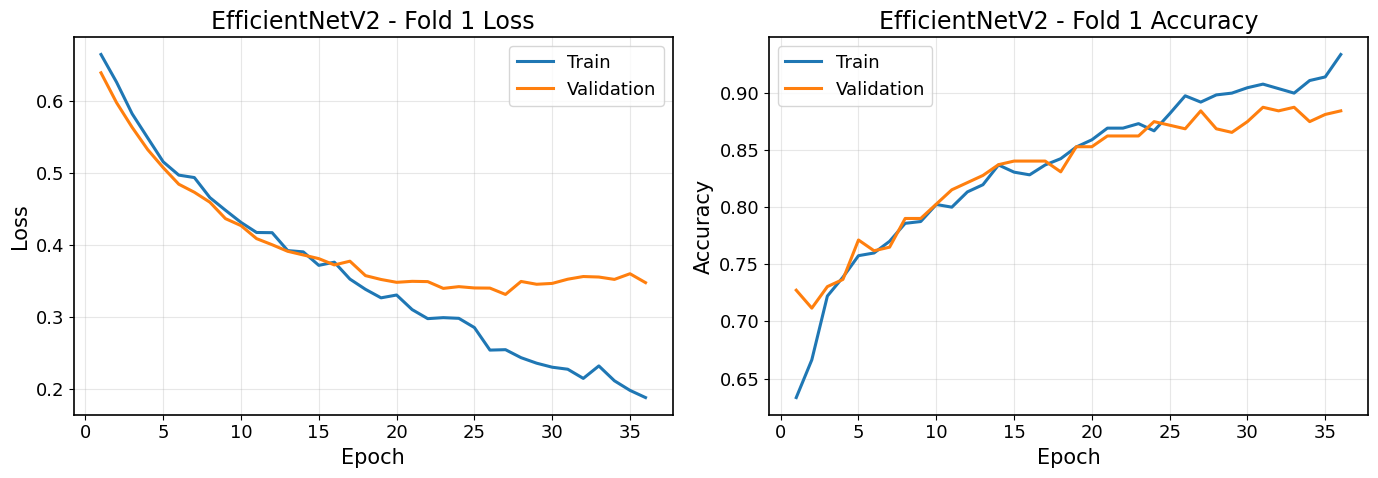

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 206MB/s] 


    [Early Stop] Epoch 34'de durduruldu.
  -> SwinTransformer Best F1: 0.8793 (Epoch 21)


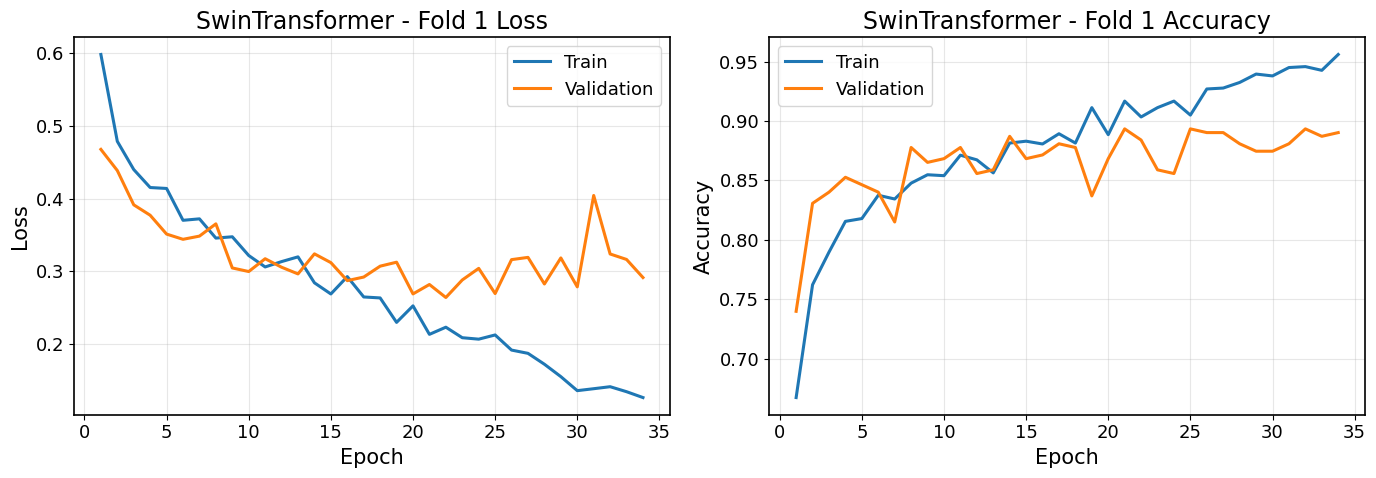

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 224MB/s]


    [Early Stop] Epoch 35'de durduruldu.
  -> ConvNeXt Best F1: 0.8820 (Epoch 30)


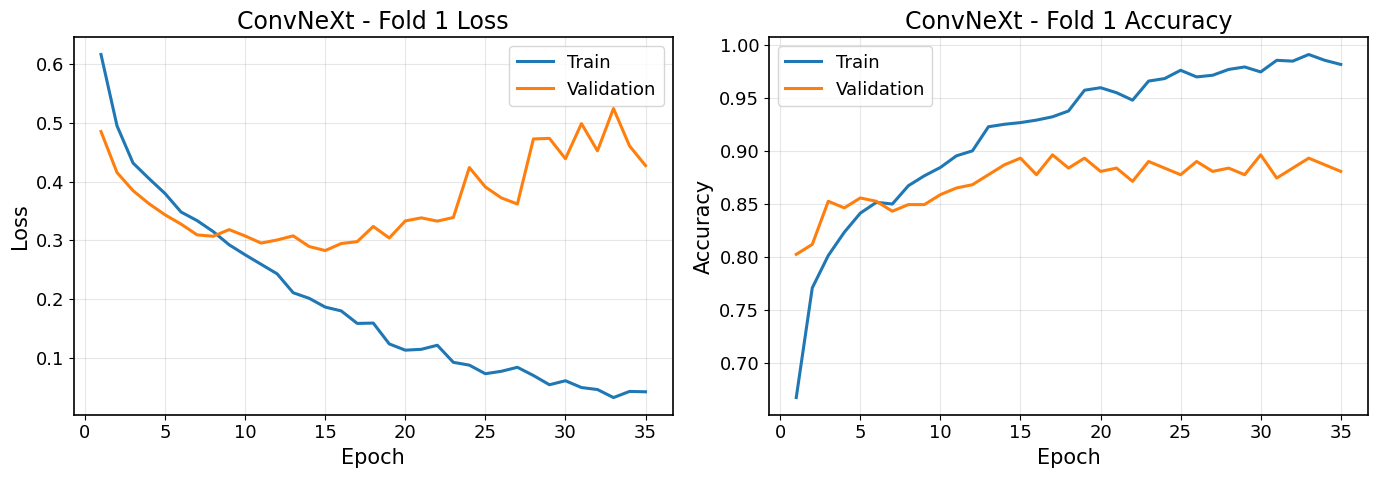


========== FOLD 2 ==========
📊 Fold Sınıf Ağırlıkları -> Benign: 0.7398, Malignant: 1.5424
    [Early Stop] Epoch 34'de durduruldu.
  -> EfficientNetV2 Best F1: 0.8407 (Epoch 20)


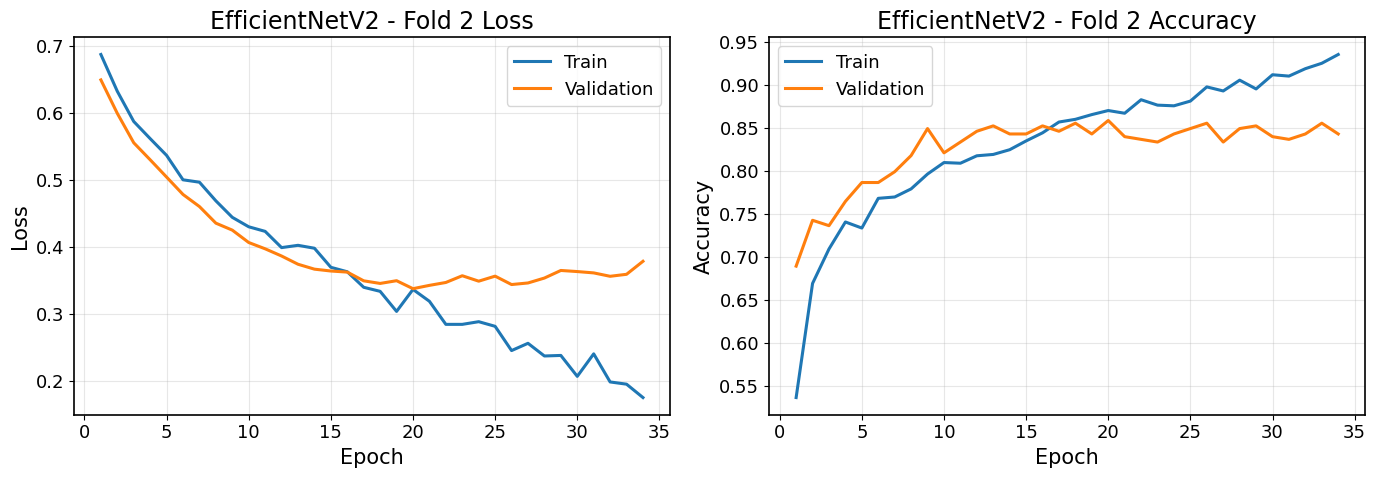

    [Early Stop] Epoch 34'de durduruldu.
  -> SwinTransformer Best F1: 0.8555 (Epoch 21)


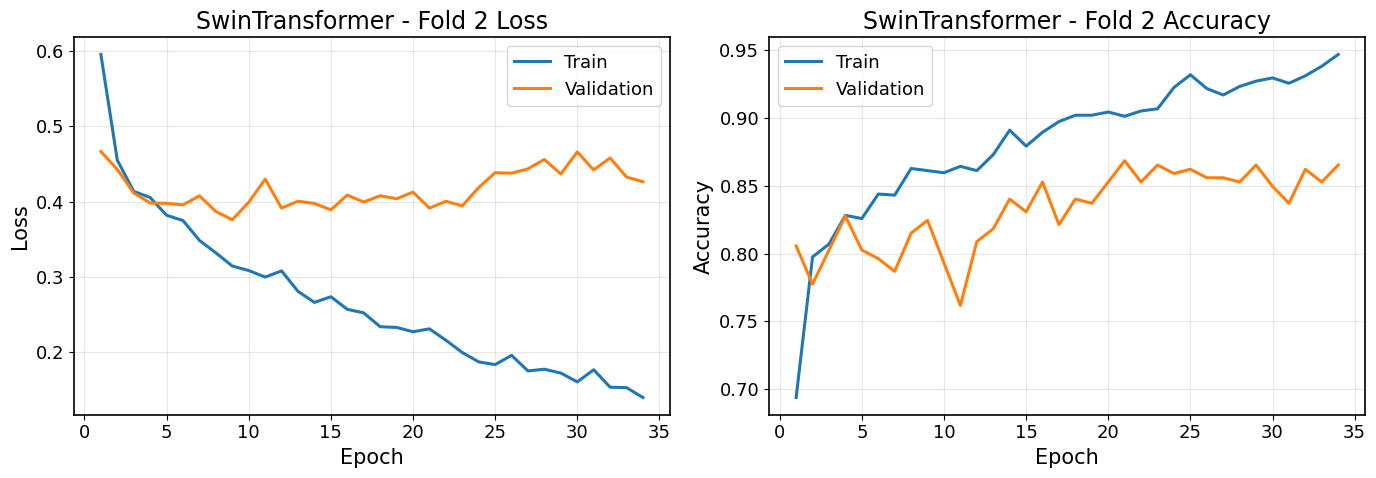

    [Early Stop] Epoch 34'de durduruldu.
  -> ConvNeXt Best F1: 0.8710 (Epoch 24)


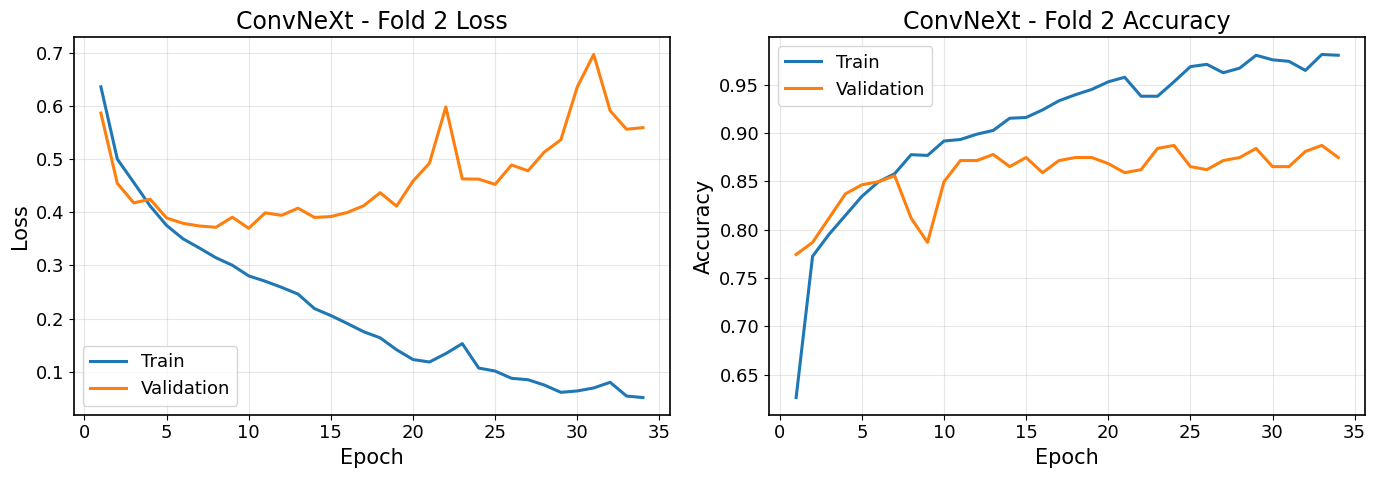


========== FOLD 3 ==========
📊 Fold Sınıf Ağırlıkları -> Benign: 0.7390, Malignant: 1.5461
    [Early Stop] Epoch 41'de durduruldu.
  -> EfficientNetV2 Best F1: 0.8142 (Epoch 36)


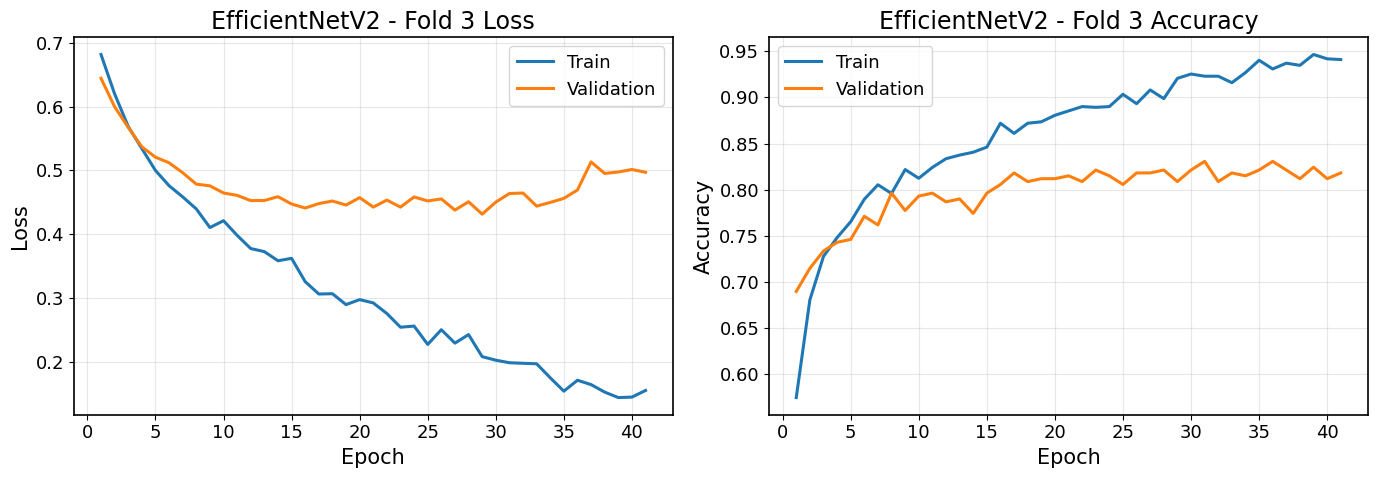

    [Early Stop] Epoch 34'de durduruldu.
  -> SwinTransformer Best F1: 0.8859 (Epoch 29)


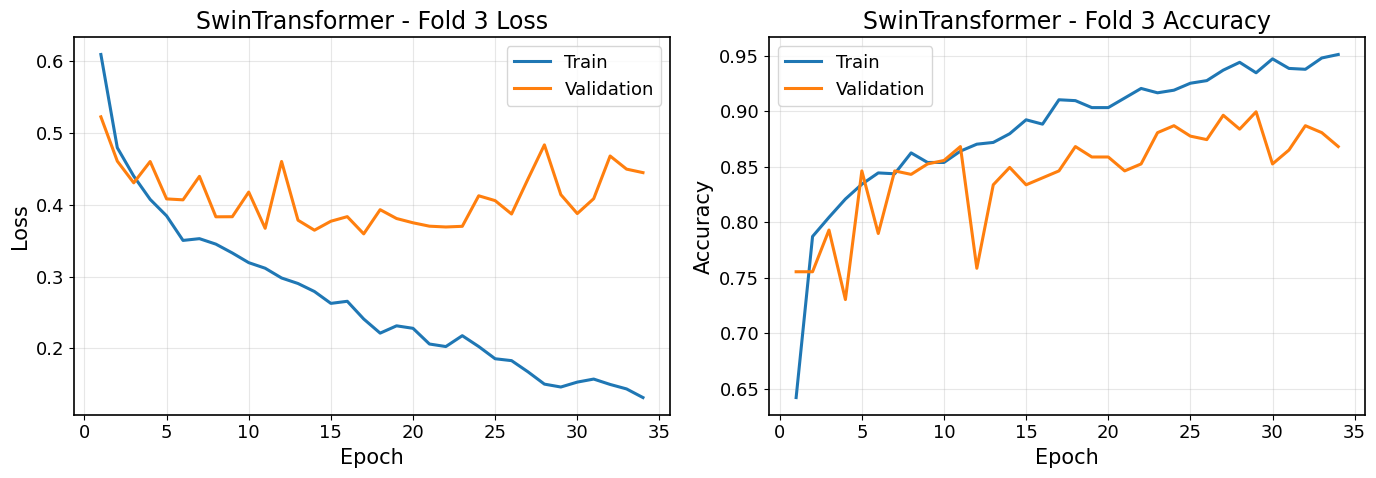

    [Early Stop] Epoch 34'de durduruldu.
  -> ConvNeXt Best F1: 0.8710 (Epoch 21)


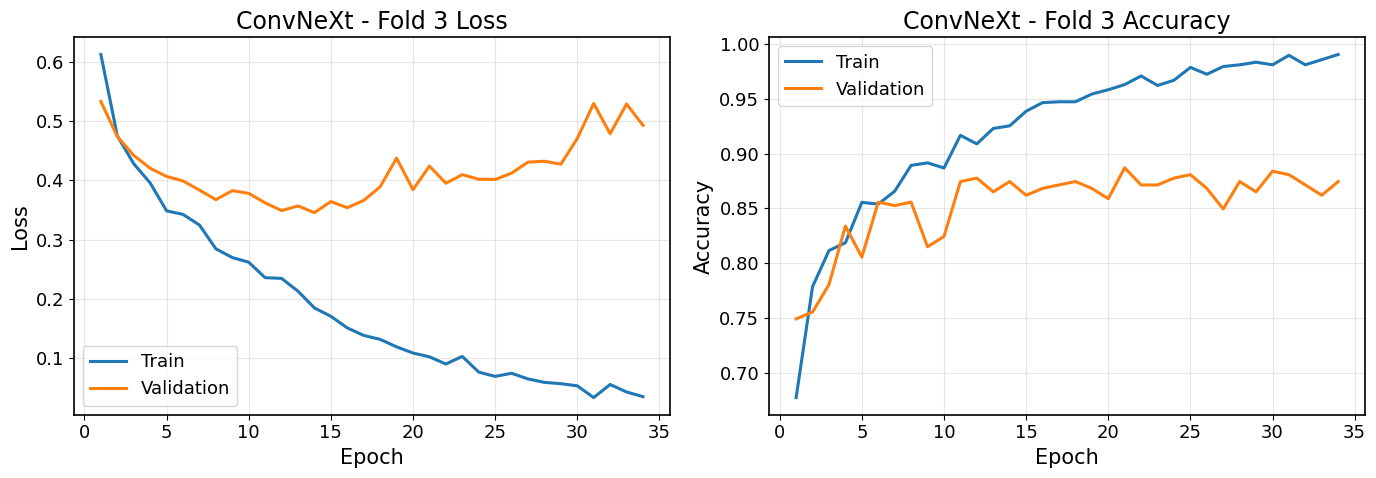


========== FOLD 4 ==========
📊 Fold Sınıf Ağırlıkları -> Benign: 0.7396, Malignant: 1.5436
    [Early Stop] Epoch 36'de durduruldu.
  -> EfficientNetV2 Best F1: 0.8162 (Epoch 31)


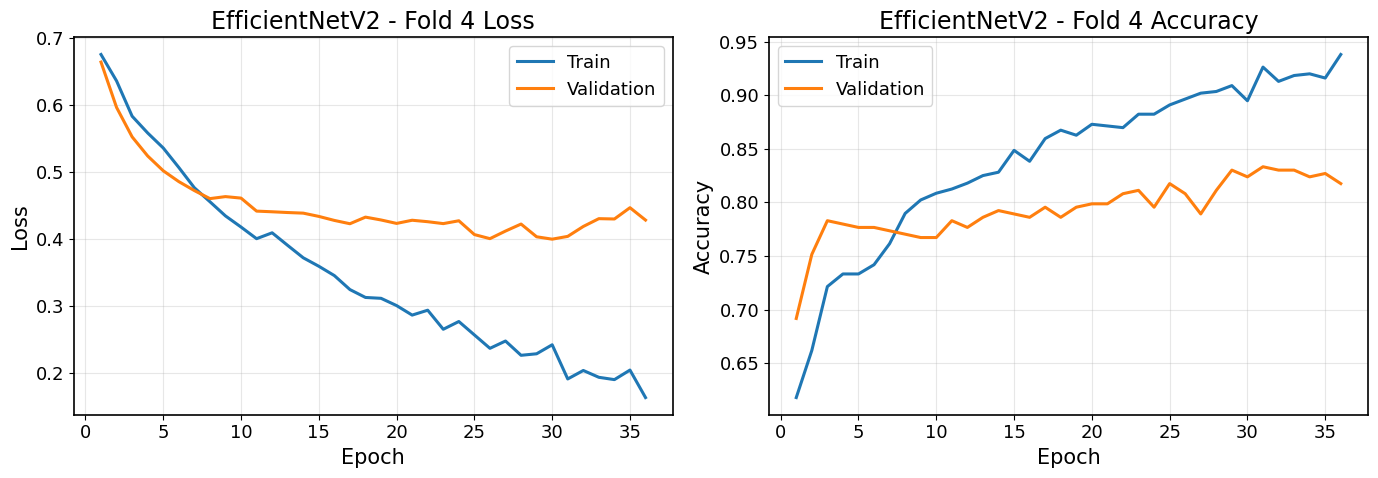

    [Early Stop] Epoch 34'de durduruldu.
  -> SwinTransformer Best F1: 0.8614 (Epoch 29)


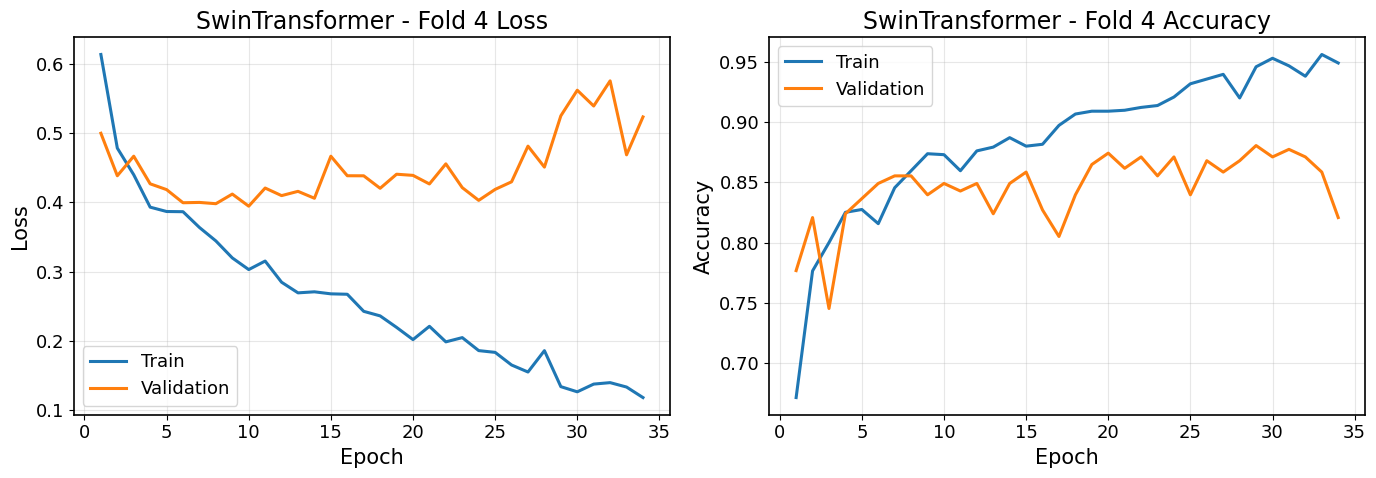

    [Early Stop] Epoch 34'de durduruldu.
  -> ConvNeXt Best F1: 0.8444 (Epoch 25)


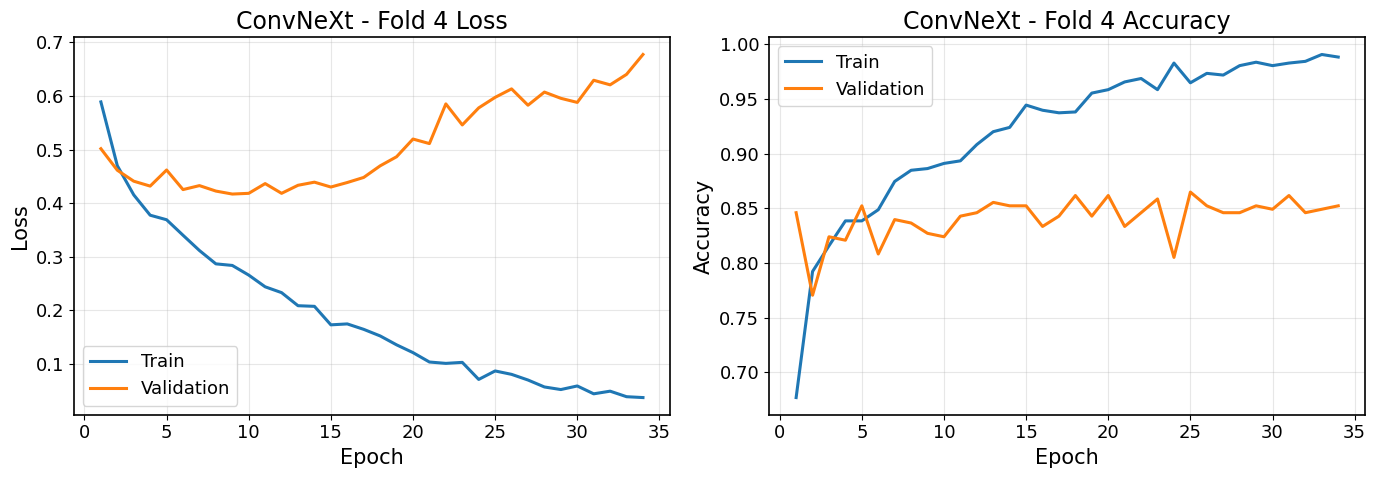


========== FOLD 5 ==========
📊 Fold Sınıf Ağırlıkları -> Benign: 0.7396, Malignant: 1.5436
    [Early Stop] Epoch 46'de durduruldu.
  -> EfficientNetV2 Best F1: 0.8649 (Epoch 41)


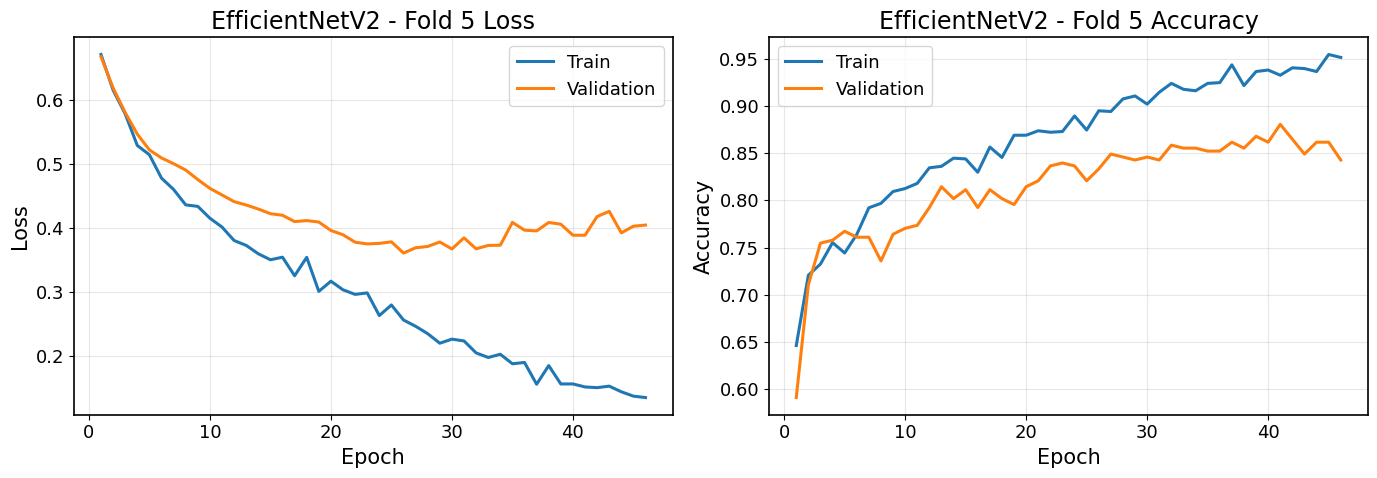

    [Early Stop] Epoch 34'de durduruldu.
  -> SwinTransformer Best F1: 0.8688 (Epoch 23)


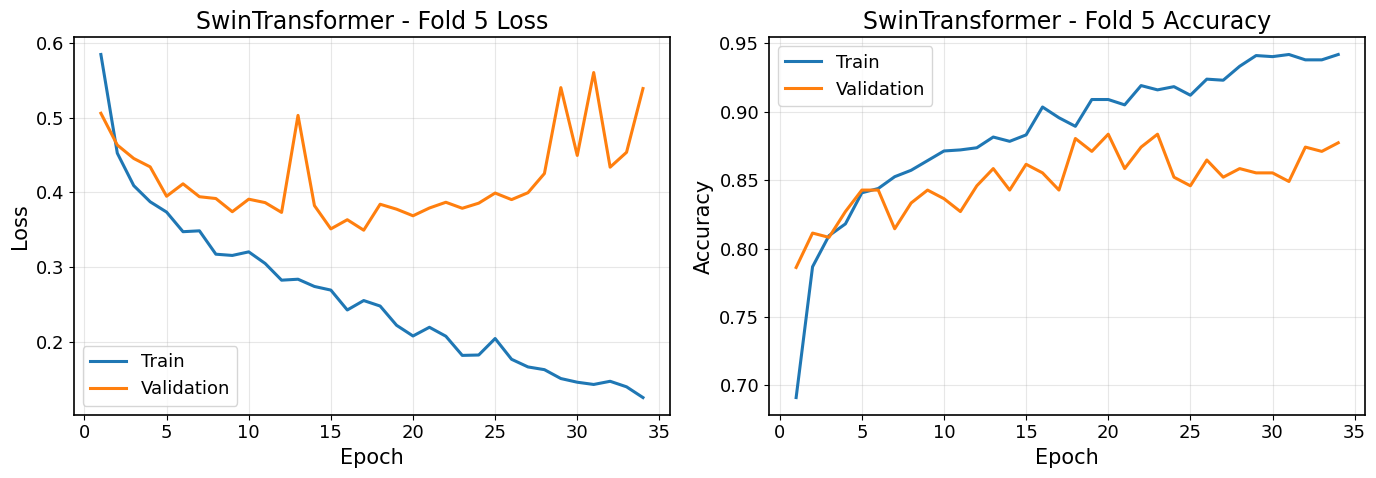

    [Early Stop] Epoch 34'de durduruldu.
  -> ConvNeXt Best F1: 0.8649 (Epoch 22)


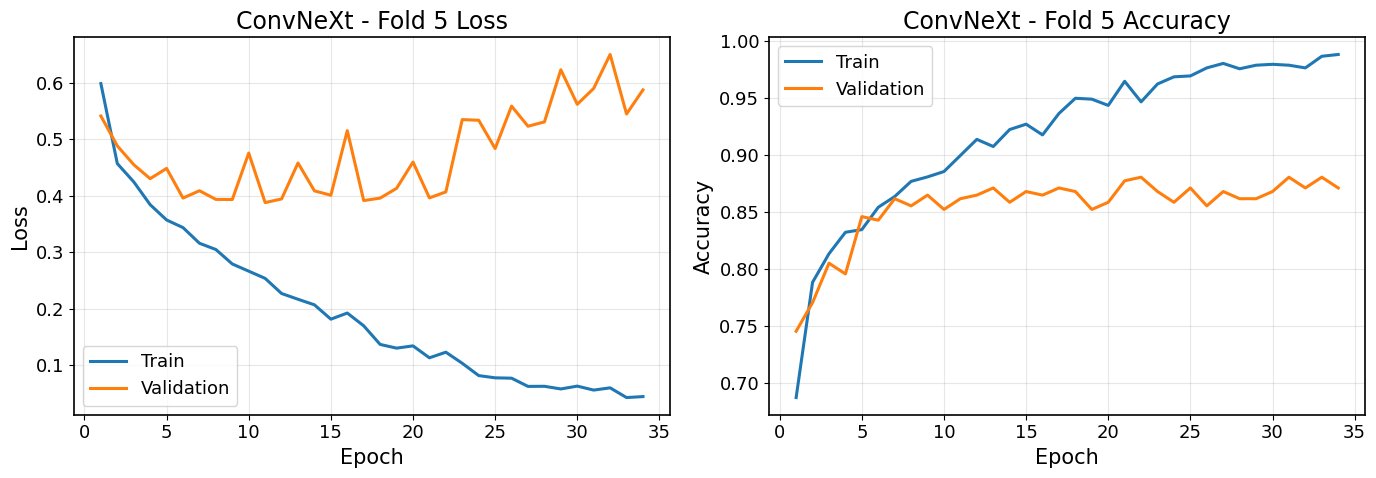


========== BAĞIMSIZ TEST SETİ ÜZERİNDE DEĞERLENDİRME ==========
Test seti için temel modellerin (Base Models) tahminleri birleştiriliyor...

 📊 BUS-BRA: TEKİL MODELLER VE STACKING ENSEMBLE KARŞILAŞTIRMASI
EfficientNetV2   -> Accuracy: 0.8617 | Precision: 0.8413 | Recall: 0.8432 | F1: 0.8423
SwinTransformer  -> Accuracy: 0.8865 | Precision: 0.8669 | Recall: 0.8788 | F1: 0.8723
ConvNeXt         -> Accuracy: 0.8759 | Precision: 0.8574 | Recall: 0.8595 | F1: 0.8584
---------------------------------------------------------------------------
🔥 ENSEMBLE       -> Accuracy: 0.8865 | Precision: 0.8678 | Recall: 0.8760 | F1: 0.8717

--- Makale İçin Bağımsız Test Seti Sonuçları (Unseen Data) ---
              precision    recall  f1-score   support

      benign       0.93      0.91      0.92       191
   malignant       0.81      0.85      0.83        91

    accuracy                           0.89       282
   macro avg       0.87      0.88      0.87       282
weighted avg       0.89      0.89 

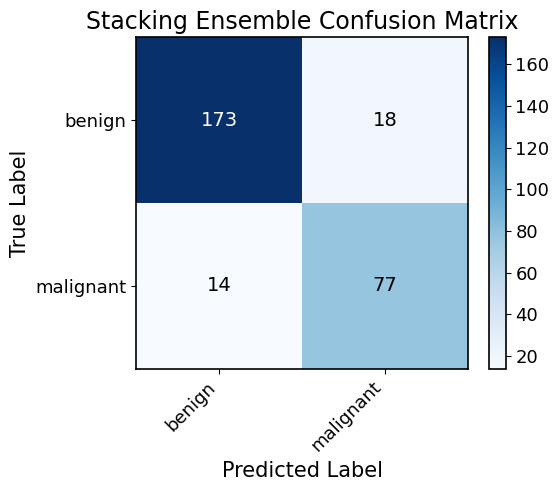

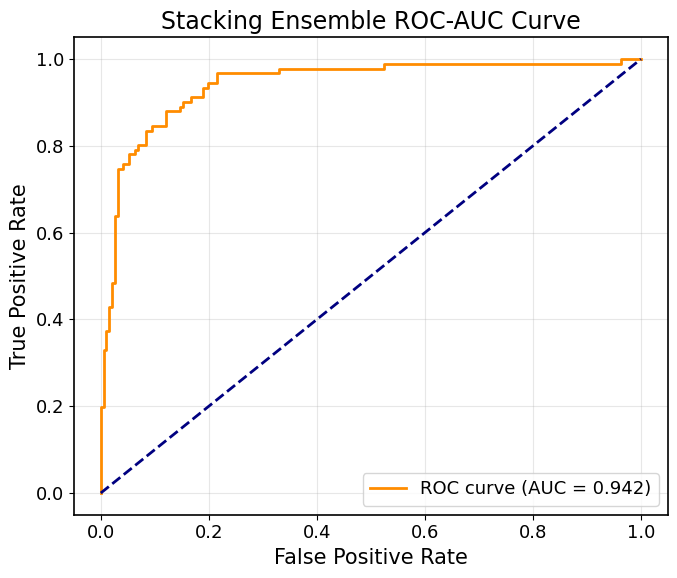

✅ İşlem Tamamlandı. Meta-model kaydedildi.


In [1]:
# =========================================================================================
# BUS-BRA Breast Cancer Classification - K-Fold & Stacking Ensemble (With Class Weights)
# =========================================================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import joblib
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.model_selection import train_test_split
!pip install grad-cam
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.2,
    "svg.fonttype": "none"
})

# ===============================
# 1. SETTINGS (AYARLAR)
# ===============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE = 32

# DEĞİŞTİRİLEN KISIM:
EPOCHS = 100             # 30'dan sonra eğitimin devam edebilmesi için üst limit artırıldı
EARLY_START = 30         # Early stopping artık 30. epoch'tan ÖNCE devreye girmeyecek
PATIENCE = 5             # 30. epoch'tan sonra F1 skoru 5 epoch boyunca artmazsa eğitim duracak

LR = 1e-4

# Orijinal Kaggle Input Dizini
DATA_DIR = "/kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA"
CSV_PATH = os.path.join(DATA_DIR, "bus_data.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "Images")
MASKS_DIR = os.path.join(DATA_DIR, "Masks")

CLASS_NAMES = ["benign", "malignant"]
NUM_CLASSES = 2

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ===============================
# 2. DATASET & TRANSFORMS
# ===============================
class BUSBraDataset(Dataset):
    def __init__(self, pairs, labels, transform=None):
        self.pairs = pairs  
        self.labels = labels
        self.transform = transform

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        label = self.labels[idx]
        
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        
        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert("L"))
            coords = np.argwhere(mask > 0)
            if coords.size > 0:
                y_min, x_min = coords.min(axis=0)
                y_max, x_max = coords.max(axis=0)
                img = img.crop((max(0, x_min-10), max(0, y_min-10), min(w, x_max+10), min(h, y_max+10)))
        else:
            img = img.crop((w*0.15, h*0.15, w*0.85, h*0.85))

        if self.transform: img = self.transform(img)
        return img, label

def load_busbra_full():
    df = pd.read_csv(CSV_PATH)
    pairs, labels = [], []
    label_map = {"benign": 0, "malignant": 1}
    
    for _, row in df.iterrows():
        img_id = str(row["ID"]).strip()
        pathology = str(row["Pathology"]).strip().lower()
        
        if pathology not in label_map: continue
            
        img_filename = f"{img_id}.png"
        mask_filename = f"{img_id.replace('bus_', 'mask_')}.png"
        
        img_path = os.path.join(IMAGES_DIR, img_filename)
        mask_path = os.path.join(MASKS_DIR, mask_filename)
        
        if os.path.exists(img_path):
            pairs.append((img_path, mask_path))
            labels.append(label_map[pathology])
            
    print(f"✅ Toplam {len(pairs)} görüntü CSV'den okundu.")
    return pairs, labels

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===============================
# 3. MODEL FACTORIES
# ===============================
def get_convnext():
    m = models.convnext_tiny(weights="IMAGENET1K_V1")
    m.classifier[2] = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier[2].in_features, NUM_CLASSES))
    return m.to(DEVICE), m.features, m.classifier

def get_efficientnet_v2():
    m = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
    m.classifier[1] = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m.to(DEVICE), m.features, m.classifier

def get_swin():
    m = models.swin_t(weights="IMAGENET1K_V1")
    m.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.head.in_features, NUM_CLASSES))
    return m.to(DEVICE), m.features, m.head

architectures = [
    ("EfficientNetV2", get_efficientnet_v2),
    ("SwinTransformer", get_swin),
    ("ConvNeXt", get_convnext)
]

# ===============================
# 4. UTILS & PLOTS
# ===============================
def plot_training_curves(history, model_name, fold_num, save=True):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss Curve
    ax[0].plot(epochs, history["train_loss"], label="Train")
    ax[0].plot(epochs, history["val_loss"], label="Validation")
    ax[0].set_title(f"{model_name} - Fold {fold_num} Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # Accuracy Curve
    ax[1].plot(epochs, history["train_acc"], label="Train")
    ax[1].plot(epochs, history["val_acc"], label="Validation")
    ax[1].set_title(f"{model_name} - Fold {fold_num} Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    if save:
        plt.savefig(f"{model_name}_fold{fold_num}_training.svg", format="svg", bbox_inches="tight")
    plt.show()
# ===============================
# 5. TRAINING HELPER
# ===============================
def train_one_fold(model_fn, train_loader, val_loader, fold, name, class_weights_tensor):
    model, backbone, head = model_fn()
    
    # Differential Learning Rate
    optimizer = torch.optim.AdamW([
        {'params': backbone.parameters(), 'lr': LR / 10},
        {'params': head.parameters(), 'lr': LR}
    ], weight_decay=0.05)
    
    # Class Weights Entegre Edildi
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": []
    }

    best_f1, best_epoch, patience_counter = 0, 0, 0
    save_path = f"{name}_fold{fold}.pth"
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        train_preds, train_trues = [], []

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            tr_loss += loss.item()
            preds = torch.argmax(outputs, 1)
            tr_correct += (preds == lbls).sum().item()
            tr_total += lbls.size(0)

            train_preds.extend(preds.cpu().numpy())
            train_trues.extend(lbls.cpu().numpy())

        train_f1 = f1_score(train_trues, train_preds, average="macro")

        model.eval()
        val_loss, val_preds, val_trues = 0, [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs)
                val_loss += criterion(out, lbls).item()
                val_preds.extend(torch.argmax(out, 1).cpu().numpy())
                val_trues.extend(lbls.cpu().numpy())

        val_f1 = f1_score(val_trues, val_preds, average="macro")

        history["train_loss"].append(tr_loss/len(train_loader))
        history["val_loss"].append(val_loss/len(val_loader))
        history["train_acc"].append(tr_correct/tr_total)
        history["val_acc"].append(accuracy_score(val_trues, val_preds))
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        # Early Stopping & Model Checkpointing
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        elif epoch >= EARLY_START:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"    [Early Stop] Epoch {epoch}'de durduruldu.")
                break
                
    del model, optimizer; gc.collect(); torch.cuda.empty_cache()
    return save_path, best_epoch, best_f1, history
# =======================================================
# 6. TRAIN/VAL/TEST SPLIT & CROSS VALIDATION LOOP
# =======================================================
paths, labels = load_busbra_full()
paths_np, labels_np = np.array(paths, dtype=object), np.array(labels)

# 1. BAĞIMSIZ TEST SETİNİ AYIRMA (%15) - Asla eğitime girmeyecek!
X_cv, X_test, y_cv, y_test = train_test_split(
    paths_np, labels_np, 
    test_size=0.15, 
    stratify=labels_np, 
    random_state=SEED
)

print(f"Cross-Validation (Train+Val) için ayrılan veri: {len(X_cv)}")
print(f"Bağımsız Test (Unseen Data) için ayrılan veri: {len(X_test)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# OOF matrisi artık sadece K-Fold verisi (X_cv) boyutunda
oof_features = np.zeros((len(X_cv), len(architectures) * NUM_CLASSES))
oof_labels = y_cv.copy()
arch_epochs = {name: [] for name, _ in architectures}

# Test aşamasında kullanmak üzere eğitilen modellerin dosya yollarını tutalım
saved_model_paths = {name: [] for name, _ in architectures}

print(f"\nStarting Cross-Validation on {len(X_cv)} images...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n========== FOLD {fold+1} ==========")
    
    # Fold bazlı sınıf ağırlıklarını hesapla
    fold_train_labels = y_cv[train_idx]
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(fold_train_labels), y=fold_train_labels)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    print(f"📊 Fold Sınıf Ağırlıkları -> Benign: {class_weights[0]:.4f}, Malignant: {class_weights[1]:.4f}")

    # DataLoader'lara artık paths_np değil, X_cv verilerini veriyoruz
    train_loader = DataLoader(BUSBraDataset(X_cv[train_idx], y_cv[train_idx], train_tfms), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(BUSBraDataset(X_cv[val_idx], y_cv[val_idx], val_tfms), batch_size=BATCH_SIZE, shuffle=False)
    
    for i, (name, model_fn) in enumerate(architectures):
        save_path, b_epoch, b_f1, hist = train_one_fold(model_fn, train_loader, val_loader, fold, name, class_weights_tensor)
        arch_epochs[name].append(b_epoch)
        saved_model_paths[name].append(save_path) # Test aşaması için kaydet
        print(f"  -> {name} Best F1: {b_f1:.4f} (Epoch {b_epoch})")
        
        plot_training_curves(hist, name, fold+1)
        
        # OOF Predictions Extraction
        model, _, _ = model_fn()
        model.load_state_dict(torch.load(save_path))
        model.eval()
        fold_probs = []
        with torch.no_grad():
            for imgs, _ in val_loader:
                out = model(imgs.to(DEVICE))
                fold_probs.append(torch.softmax(out, dim=1).cpu().numpy())
                
        # Her modelin tahminlerini uygun sütunlara yerleştir
        oof_features[val_idx, i*NUM_CLASSES:(i+1)*NUM_CLASSES] = np.vstack(fold_probs)
        del model; gc.collect(); torch.cuda.empty_cache()


# =======================================================
# 7. TEST SET INFERENCE & STACKING ENSEMBLE REPORT
# =======================================================
print("\n========== BAĞIMSIZ TEST SETİ ÜZERİNDE DEĞERLENDİRME ==========")

# 1. Meta-Modeli OOF (Validation) tahminleriyle eğit
meta_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
meta_model.fit(oof_features, oof_labels)

# 2. Test Seti için DataLoader oluştur
test_loader = DataLoader(BUSBraDataset(X_test, y_test, val_tfms), batch_size=BATCH_SIZE, shuffle=False)

# 3. Test verisi üzerinden temel model tahminlerini çıkar (Stacking Test Features)
test_features = np.zeros((len(X_test), len(architectures) * NUM_CLASSES))

print("Test seti için temel modellerin (Base Models) tahminleri birleştiriliyor...")
for i, (name, model_fn) in enumerate(architectures):
    arch_test_probs = np.zeros((len(X_test), NUM_CLASSES))
    
    # Her mimari için 5 fold'un eğitilmiş modelini yükleyip tahminlerinin ortalamasını alıyoruz (Ensembling)
    for fold_path in saved_model_paths[name]:
        model, _, _ = model_fn()
        model.load_state_dict(torch.load(fold_path))
        model.eval()
        
        fold_probs = []
        with torch.no_grad():
            for imgs, _ in test_loader:
                out = model(imgs.to(DEVICE))
                fold_probs.append(torch.softmax(out, dim=1).cpu().numpy())
        
        arch_test_probs += np.vstack(fold_probs)
        del model; gc.collect(); torch.cuda.empty_cache()
        
    # İlgili mimarinin 5 fold ortalamasını al
    arch_test_probs /= 5.0
    test_features[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES] = arch_test_probs

# 4. Meta-Model ile Bağımsız Test Seti Tahmini
test_meta_preds = meta_model.predict(test_features)
test_meta_probs = meta_model.predict_proba(test_features)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("\n" + "="*75)
print(" 📊 BUS-BRA: TEKİL MODELLER VE STACKING ENSEMBLE KARŞILAŞTIRMASI")
print("="*75)

# 1. Tekil Modellerin Performansını Hesapla ve Yazdır
for i, (name, _) in enumerate(architectures):
    # İlgili mimarinin test seti olasılıklarını test_features içinden çek
    arch_probs = test_features[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES]
    
    # Olasılıkları sınıf tahminine (0: benign, 1: malignant) çevir
    arch_preds = np.argmax(arch_probs, axis=1)
    
    # Metrikleri hesapla
    acc = accuracy_score(y_test, arch_preds)
    prec = precision_score(y_test, arch_preds, average="macro")
    rec = recall_score(y_test, arch_preds, average="macro")
    f1 = f1_score(y_test, arch_preds, average="macro")
    
    print(f"{name:16s} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

print("-" * 75)

# 2. Stacking Meta-Model (Ensemble) Performansını Hesapla ve Yazdır
ens_acc = accuracy_score(y_test, test_meta_preds)
ens_prec = precision_score(y_test, test_meta_preds, average="macro")
ens_rec = recall_score(y_test, test_meta_preds, average="macro")
ens_f1 = f1_score(y_test, test_meta_preds, average="macro")

print(f"{'🔥 ENSEMBLE':16s} -> Accuracy: {ens_acc:.4f} | Precision: {ens_prec:.4f} | Recall: {ens_rec:.4f} | F1: {ens_f1:.4f}")
print("="*75)

# 3. Klasik Sınıflandırma Raporu
print("\n--- Makale İçin Bağımsız Test Seti Sonuçları (Unseen Data) ---")
print(classification_report(y_test, test_meta_preds, target_names=CLASS_NAMES))

def plot_confusion_matrix_svg(y_true, y_pred, class_names):
    # class_names zaten ["benign", "malignant"] olarak tanımlı olduğu için sorun yok
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title("Stacking Ensemble Confusion Matrix")

    # Matris içindeki sayıları yazdır
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", 
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)

    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig("busbra_confusion_matrix.svg", format="svg", bbox_inches="tight")
    plt.show()

def plot_roc_auc_svg(y_true, y_probs, class_names):
    # Binary classification için pozitif sınıf (malignant) olasılıklarını kullanıyoruz
    y_true_bin = label_binarize(y_true, classes=[0, 1])
    fpr, tpr, _ = roc_curve(y_true_bin, y_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    fig = plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Stacking Ensemble ROC-AUC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("busbra_roc_auc.svg", format="svg", bbox_inches="tight")
    plt.show()
# Görselleştirmeleri y_test (gerçek etiketler) ve test_meta_preds/probs ile çiz
plot_confusion_matrix_svg(y_test, test_meta_preds, CLASS_NAMES)
plot_roc_auc_svg(y_test, test_meta_probs, CLASS_NAMES)

# ===============================
# 8. SAVE & EXPORT
# ===============================
joblib.dump(meta_model, "busbra_stacking_meta_model.pkl")
print("✅ İşlem Tamamlandı. Meta-model kaydedildi.")

In [2]:
from sklearn.metrics import classification_report
import pandas as pd

# Swap the generic placeholders for your actual variables
# Adding target_names=CLASS_NAMES keeps your rows named "benign" and "malignant" rather than 0 and 1
report = classification_report(y_test, test_meta_preds, target_names=CLASS_NAMES, output_dict=True)

# Convert to DataFrame and print
df_report = pd.DataFrame(report).transpose()
print(df_report)

# Save to CSV as originally intended
df_report.to_csv("classification_report.csv")

              precision    recall  f1-score     support
benign         0.925134  0.905759  0.915344  191.000000
malignant      0.810526  0.846154  0.827957   91.000000
accuracy       0.886525  0.886525  0.886525    0.886525
macro avg      0.867830  0.875957  0.871650  282.000000
weighted avg   0.888150  0.886525  0.887145  282.000000


In [3]:
from sklearn.metrics import classification_report

report = classification_report(y_test, test_meta_preds, output_dict=True)
print(pd.DataFrame(report).transpose())

              precision    recall  f1-score     support
0              0.925134  0.905759  0.915344  191.000000
1              0.810526  0.846154  0.827957   91.000000
accuracy       0.886525  0.886525  0.886525    0.886525
macro avg      0.867830  0.875957  0.871650  282.000000
weighted avg   0.888150  0.886525  0.887145  282.000000


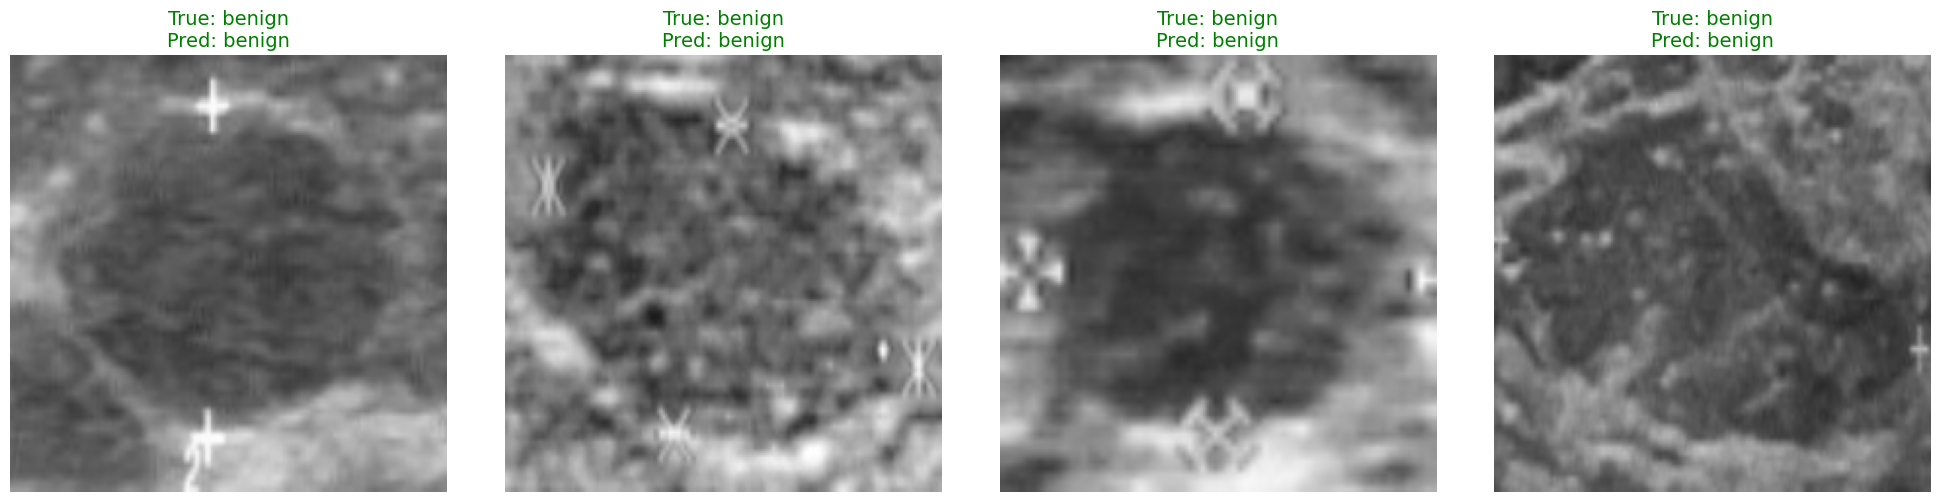

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Görselleri normalizasyondan geri çevirmek için yardımcı fonksiyon
def unnormalize_img(tensor):
    img = tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np = np.array([0.229, 0.224, 0.225])
    img = std_np * img + mean_np
    return np.clip(img, 0, 1)

correct_samples = []
incorrect_samples = []

# test_loader (shuffle=False) ile test_meta_preds tamamen aynı sıradadır.
# Bu yüzden global bir indeks tutarak tahminleri eşleştirebiliriz.
global_idx = 0

for imgs, lbls in test_loader:
    imgs = imgs.to(DEVICE)
    lbls_np = lbls.numpy()
    
    for i in range(len(lbls_np)):
        true_label_idx = y_test[global_idx]
        pred_label_idx = test_meta_preds[global_idx]
        
        is_correct = (true_label_idx == pred_label_idx)
        
        sample = {
            'tensor': imgs[i].unsqueeze(0),
            'image': unnormalize_img(imgs[i]),
            'true_label': CLASS_NAMES[true_label_idx],
            'pred_label': CLASS_NAMES[pred_label_idx],
            'true_idx': true_label_idx
        }
        
        if is_correct and len(correct_samples) < 4:
            correct_samples.append(sample)
        elif not is_correct and len(incorrect_samples) < 4:
            incorrect_samples.append(sample)
            
        global_idx += 1
        
    if len(correct_samples) >= 4 and len(incorrect_samples) >= 4:
        break
# =========================================
# GÖRSELLEŞTİRME 1: DOĞRU TAHMİNLER
# =========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, sample in enumerate(correct_samples):
    axes[i].imshow(sample['image'])
    axes[i].set_title(
        f"True: {sample['true_label']}\nPred: {sample['pred_label']}",
        color="green",
        fontsize=14
    )
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("busbra_correct_preds.svg", format="svg", bbox_inches="tight")
plt.show()

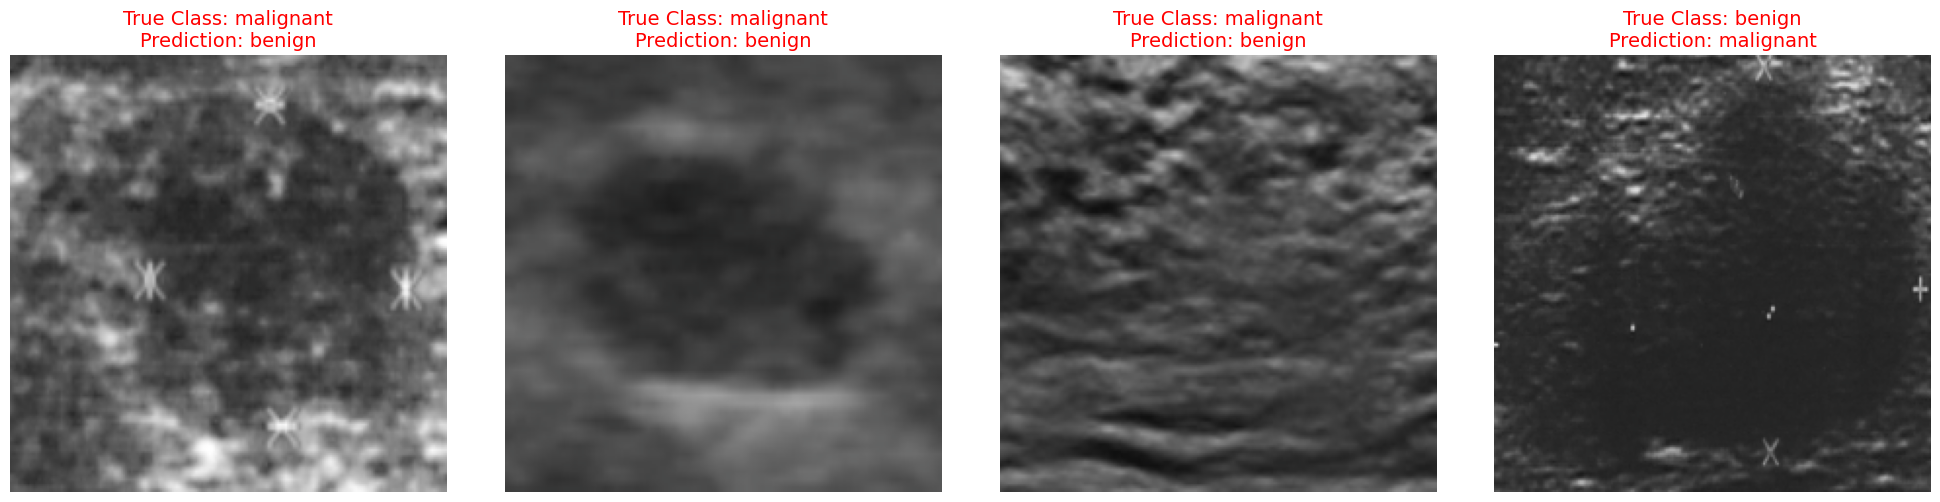

In [5]:
# =========================================
# GÖRSELLEŞTİRME 2: YANLIŞ TAHMİNLER
# =========================================
num_incorrect = len(incorrect_samples)

if num_incorrect == 0:
    print("Harika! Stacking modeliniz bu test seti/batch üzerinde hiç hata yapmadı.")
else:
    fig, axes = plt.subplots(1, num_incorrect, figsize=(5 * num_incorrect, 5))
    
    # Sadece 1 hata varsa iterasyon sorunu çıkmaması için listeye çevir
    if num_incorrect == 1:
        axes = [axes]
        
    for i, sample in enumerate(incorrect_samples):
        axes[i].imshow(sample['image'])
        axes[i].set_title(f"True Class: {sample['true_label']}\nPrediction: {sample['pred_label']}", color="red", fontsize=14)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("busbra_incorrect_preds.svg", format="svg", bbox_inches="tight")
    plt.show()

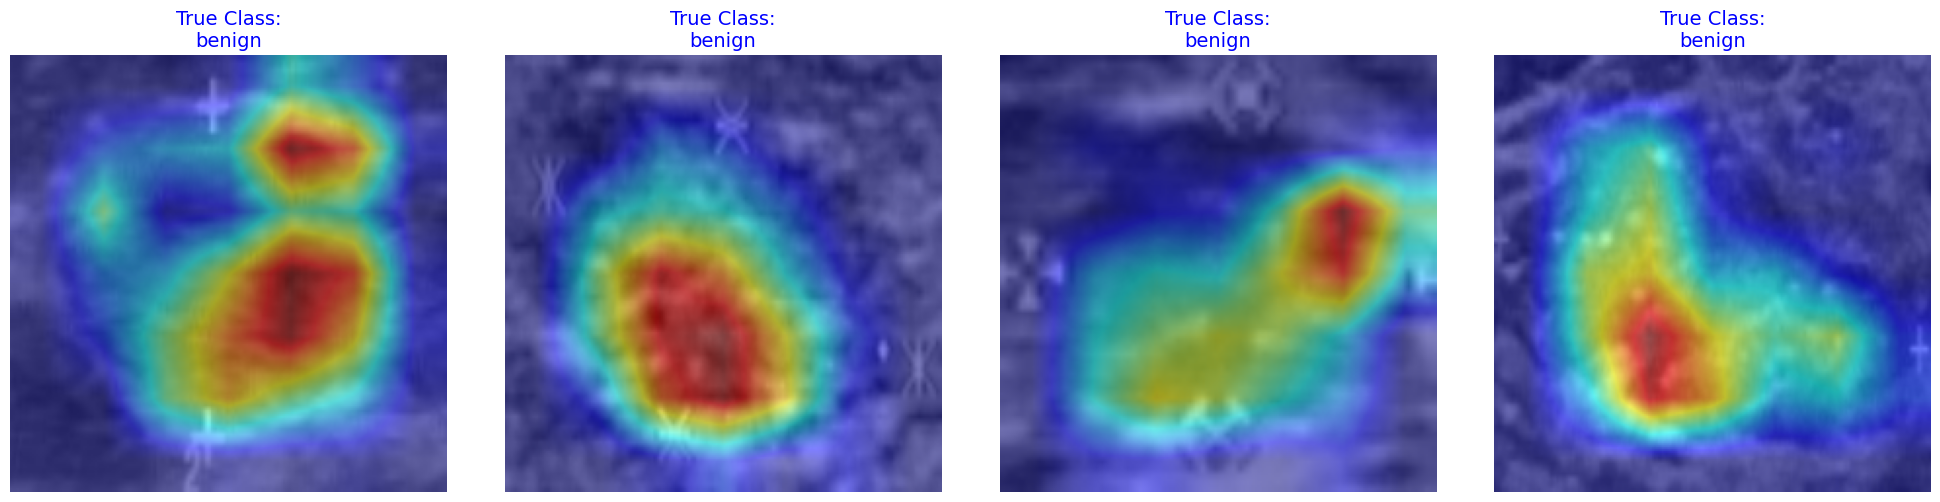

In [6]:
# =========================================
# GÖRSELLEŞTİRME 3: DOĞRU TAHMİNLER İÇİN GRAD-CAM
# =========================================
# Görselleştirme için EfficientNetV2'nin ilk Fold ağırlıklarını yüklüyoruz
model_cam, _, _ = get_efficientnet_v2()
model_path = saved_model_paths["EfficientNetV2"][0] 
model_cam.load_state_dict(torch.load(model_path, map_location=DEVICE))
model_cam.eval()

# EfficientNetV2 için son convolution bloku
target_layers = [model_cam.features[-1]]
cam = GradCAM(model=model_cam, target_layers=target_layers)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, sample in enumerate(correct_samples):
    input_tensor = sample['tensor']
    target_class_idx = sample['true_idx']
    
    # Gerçek sınıfa göre ısı haritasını çıkartıyoruz
    targets = [ClassifierOutputTarget(target_class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Orijinal resim ile Isı Haritasını (Heatmap) birleştir
    cam_image = show_cam_on_image(sample['image'], grayscale_cam, use_rgb=True)
    
    axes[i].imshow(cam_image)
    axes[i].set_title(f"True Class:\n{sample['true_label']}", color="blue", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("busbra_gradcam.svg", format="svg", bbox_inches="tight")
plt.show()

# Bellek temizliği
del model_cam
import gc
gc.collect()
torch.cuda.empty_cache()